# 02 · V7 Breadth / orthogonalized composite — more independent bets

**Angle:** Grinold IR=TC·IC·√BR — breadth comes only from *independent* bets, and the ~18 category×tenor cells co-move so effective breadth `BR_eff=N/[1+(N−1)ρ]` collapses. Fix: **Gram–Schmidt** (level→flow⊥→accel⊥), a **breadth-diffusion** index, a **dispersion** index, and **detoning/ICA**. *Refs: Grinold–Kahn; Clarke–de Silva–Thorley; López de Prado detoning.*

In [1]:
import sys, os
# Make the notebook self-sufficient: walk up from cwd to the repo root (dir containing `positioning`).
_root = os.getcwd()
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, "positioning")):
    _root = os.path.dirname(_root)
if _root not in sys.path:
    sys.path.insert(0, _root)

import warnings; warnings.filterwarnings("ignore")
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import display
except Exception:
    def display(x): print(x)

plt.rcParams.update({
    "figure.figsize": (11, 4.2), "figure.dpi": 110, "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
})
ORANGE="#FF8200"; GREY="#3C3C3C"; BLUE="#1F4E79"; RED="#C00000"; GREEN="#2E7D32"; PURPLE="#7030A0"; TEAL="#0F9D9D"

from positioning.versions import base, compare, richness, dsp, transforms
from positioning.versions import params as P
from positioning.versions.base import responsiveness

def show(df, n=None):
    """Render a DataFrame/dict, truncated."""
    try:
        display(df if n is None else df.head(n))
    except Exception:
        print(df)

def zline(ax, bounded=False):
    """Draw crowd bands for a composite axis."""
    if bounded:
        ax.axhline(80, color=RED, ls="--", lw=0.7); ax.axhline(20, color=GREEN, ls="--", lw=0.7)
    else:
        for k in (1.5, -1.5): ax.axhline(k, color=GREY, ls="--", lw=0.6)
        ax.axhline(0, color=GREY, lw=0.4)

def crossings(z, level=0.0):
    """Count sign changes of (z-level): a proxy for 'deviations per unit time'."""
    s = z.dropna().astype(float) - level
    return int((np.sign(s).diff().abs() > 0).sum())

print("loaded versions package — building shared inputs (cache-first)…")
inp = base.load_inputs()
y10 = inp.y10_w
print(f"inputs: {len(inp.report_dates)} weekly dates {inp.report_dates.min().date()}..{inp.report_dates.max().date()}")

loaded versions package — building shared inputs (cache-first)…


inputs: 422 weekly dates 2018-06-19..2026-07-14


## Build V7 (default) and score it against V0

In [2]:
inp, results = compare.build_all()
r = results["v7"]; c = r.composite.dropna()
print(r.name); print(r.description)
print(f"n finite={len(c)}  latest={(c.iloc[-1] if len(c) else float('nan')):+.4f}  0-crossings={crossings(richness.to_z(c, r.bounded))}")
print("meta keys:", list(r.meta)[:20])

/home/codespace/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


/home/codespace/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/codespace/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


/home/codespace/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/codespace/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


V7 Breadth / orthogonalized composite
Gram–Schmidt-orthogonalized level/flow/accel + cross-sectional breadth-diffusion and dispersion, combined by equal/rank/detoned-PCA/ICA; reports BR_eff so co-moving cells aren't double-counted. POSITIVE = crowded net long.
n finite=397  latest=+0.1572  0-crossings=96
meta keys: ['combine', 'orthogonalize', 'panel', 'norm_mode', 'components', 'level_latest', 'flow_latest', 'accel_latest', 'breadth_latest', 'dispersion_latest', 'combined_latest', 'BR_eff', 'N', 'rho', 'n_finite', 'note']


In [3]:
# Score the default build vs V0 (strict gate)
s = richness.score(r.composite, inp.y10_w, bounded=r.bounded, baseline=results["v0"].composite, name="v7")
def _flat(d, pre=""):
    for k, v in (d or {}).items():
        if isinstance(v, dict): _flat(v, pre+str(k)+".")
        else: print(f"  {pre+str(k):38s} {v}")
for sec in ("richness","structure","gate"):
    print(f"[{sec}]"); _flat(s.get(sec))

[richness]
  crossings_per_yr.0                     12.574307304785894
  crossings_per_yr.1                     8.775818639798489
  crossings_per_yr.2                     1.4408060453400502
  turns_per_yr                           24.362720403022667
  n_turns                                186
  bienayme_z                             -9.226274975786879
  n                                      397
  rice_2σ_per_yr                         0.6484150540513999
[structure]
  ou_half_life_wk                        4.069049077722806
  spectral_entropy                       0.728044507315785
  n_eff                                  35.85194512213541
[gate]
  pass                                   False
  reasons                                ['incremental IC not positive (nan); insufficient added-deviation sample (n_subset=15)', 'added-IC does not beat surrogates (p=nan ≥ 0.05, kind=iaaft)', 'CPCV OOS IC not positive (mean=-0.064, n_paths=15)', '|t| below hurdle (-0.10 ≤ 3, n_eff-adjusted)']
 

## V7 vs V0 through time

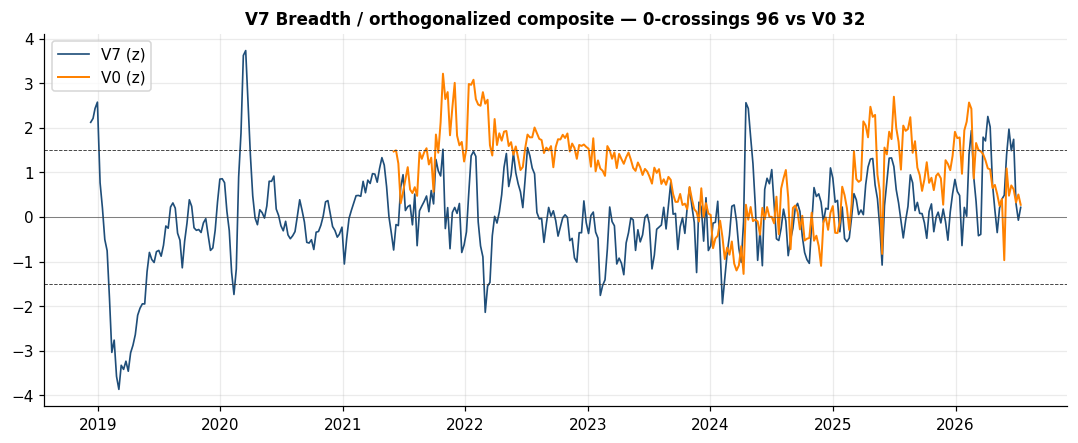

In [4]:
v0 = results["v0"].composite.dropna()
fig, ax = plt.subplots(figsize=(12, 4.4))
ax.plot(c.index, richness.to_z(c, r.bounded), color=BLUE, lw=1.1, label="V7 (z)")
ax.plot(v0.index, richness.to_z(v0, False), color=ORANGE, lw=1.3, label="V0 (z)")
zline(ax); ax.legend(loc="upper left")
ax.set_title(f"{r.name[:48]} — 0-crossings {crossings(richness.to_z(c, r.bounded))} vs V0 {crossings(richness.to_z(v0, False))}")
display(fig); plt.close(fig)

## Variants

In [5]:
cfgs = [{}, {"combine":"rank"}, {"combine":"detoned_pca"}, {"combine":"ica"}, {"orthogonalize":False}]
rows = []
for cfg in cfgs:
    rr = compare.BUILDERS["v7"](inp, cfg)
    cc = rr.composite.dropna()
    s = richness.score(rr.composite, inp.y10_w, bounded=rr.bounded, baseline=results["v0"].composite, name="v7")
    g = s.get("gate") or {}
    rows.append({"cfg": str(cfg)[:30], "n": len(cc), "latest": (cc.iloc[-1] if len(cc) else np.nan),
                 "0-cross": crossings(richness.to_z(cc, rr.bounded)),
                 "BR_eff": rr.meta.get("BR_eff"), "N": rr.meta.get("N"), "rho": rr.meta.get("rho"),
                 "incr_ic": g.get("incremental_ic"), "surr_p": g.get("surrogate_p"), "pass": g.get("pass")})
show(pd.DataFrame(rows).round(3))
print("BR_eff vs N — a real finding: the buy-side cells are OFFSETTING (asset managers long duration "
      "vs leveraged funds short), so the mean cell-z correlation rho is near-zero/negative and "
      "effective breadth is HIGH, not collapsed. The naive 'positions co-move so breadth << N' story "
      "does not hold on this panel — favourable for a breadth composite.")

,cfg,n,latest,0-cross,BR_eff,N,rho,incr_ic,surr_p,pass
0,{},397,0.157,96,33.29,12,-0.058,NaN,NaN,False
1,{'combine': 'rank'},372,-0.054,102,33.29,12,-0.058,-0.128,0.707,False
2,{'combine': 'detoned_pca'},397,-1.557,13,33.29,12,-0.058,-0.248,0.387,False
3,{'combine': 'ica'},372,2.151,42,33.29,12,-0.058,0.037,0.939,False
4,{'orthogonalize': False},397,0.094,100,33.29,12,-0.058,NaN,NaN,False


BR_eff vs N — a real finding: the buy-side cells are OFFSETTING (asset managers long duration vs leveraged funds short), so the mean cell-z correlation rho is near-zero/negative and effective breadth is HIGH, not collapsed. The naive 'positions co-move so breadth << N' story does not hold on this panel — favourable for a breadth composite.


### Note
`BR_eff ≪ N` quantifies how little genuinely-independent information the raw cross-section carries — orthogonalisation and detoning are the levers that add real breadth.